# Evolution of Sonar & Sonar Signal Processing Fundamentals
Instructors: Dr. Spencer J. Chang, Dr. Daniel D. Sternlicht

**Notebook Description:**
This notebook provides a mall sampler of the different types of interactive exercises that will be available for course attendees.

## Signal Characteristics

If we want to do analog signal processing, we must use *analog* components, like resistors, capacitors, inductors, transistors, and operational amplifiers in circuits that modify received signals. If we want to do **digital signal processing** as we are in this course, we must first receive the signal through an analog-to-digital converter.

This carries with it a series of implications. One of the biggest implications that affects us is the sampling rate.

**What do we mean by sampling rate?**

When collecting the amplitude information of incoming signals, we're restricted by our hardware (e.g., how many different amplitude levels we can receive) and *by how often we record the amplitude value of the signal.*

Let us consider *periodic* sinusoid signals that oscillate based on some period $T$.

One example is the cosine function: $x(t) = \cos\theta(t;\omega_0)$, where $\theta(t;\omega_0)=\omega_0 t = \frac{2\pi}{T}t$. It is a simple calculation to see that this signal will repeat itself at multiples of $T = \frac{2\pi}{\omega_0}$. $f_0=\frac{1}{T}$ is considered the "fundamental frequency" and determines the periodicity of this signal.

What would be more relevant for our purposes is to look at the so-called `sinc` function: $f(x) = \frac{sin(x)}{x}$. This function can be represented with a composition of multiple sinusoid functions, and this may be determined using additional Fourier math that we won't get into in this course.

Note: `numpy.sinc` computes the *normalized* `sinc` function $\frac{sin(\pi x)}{\pi x}$, so to get a signal up to 15 Hz, $x=2(15)t$.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

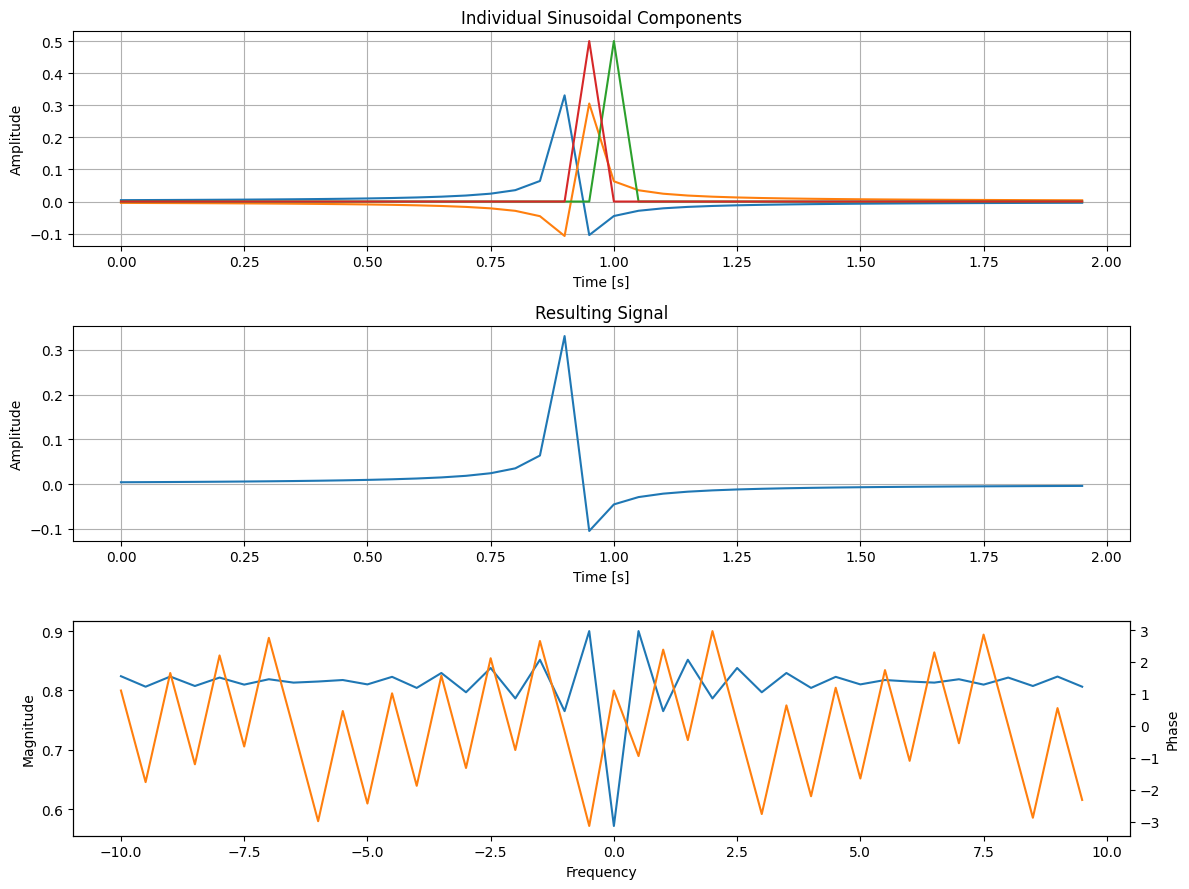

In [2]:
# -------------------------------------------------
# 1. Define a time axis (e.g., 0‑2 seconds, 1 kHz sampling)
# -------------------------------------------------
fs = 20                # Sampling frequency [Hz]
t_end = 2                # Duration [seconds]
t = np.arange(0, t_end, 1/fs)

# -------------------------------------------------
# 2. Generate (normalized) sinc function signals
# -------------------------------------------------
impulse_f = 20
sig_a = lambda t_val: (0.5+1j) * 1.0 * np.sinc(2*impulse_f*(t_val-0.912))
sig_b = lambda t_val: (0.5+1j) * 1.0 * np.sinc(2*impulse_f*(t_val-0.937))
sig_c = lambda t_val: (0.5+1j) * 1.0 * np.sinc(2*impulse_f*(t_val-1))
sig_d = lambda t_val: (0.5+1j) * 1.0 * np.sinc(2*impulse_f*(t_val-0.95))

# -------------------------------------------------
# 3. Superpose (add) the three signals
# -------------------------------------------------
one_sig = lambda t_axis: sig_a(t_axis)
two_sig = lambda t_axis: sig_a(t_axis) + sig_b(t_axis)
three_sig = lambda t_axis: sig_a(t_axis) + sig_b(t_axis) + sig_c(t_axis)

# -------------------------------------------------
# 4. Plot everything for visual verification
# -------------------------------------------------
plt.figure(figsize=(12, 9))

# Plot each component
plt.subplot(3, 1, 1)
plt.plot(t, sig_a(t).real)
plt.plot(t, sig_b(t).real)
plt.plot(t, sig_c(t).real)
plt.plot(t, sig_d(t).real)
plt.title('Individual Sinusoidal Components')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
# plt.legend(loc='upper right')
plt.grid(True)

superposed = one_sig
# superposed = two_sig
# superposed = three_sig

# Plot the superposed signal
plt.subplot(3, 1, 2)
plt.plot(t, superposed(t).real)
plt.title('Resulting Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

n_fft = len(t)
sig_fft = scipy.fft.fft(superposed(t), n=n_fft)
freq_axis = scipy.fft.fftfreq(n=n_fft, d=1/fs)

plt.subplot(3, 1, 3)
plt.plot(scipy.fft.fftshift(freq_axis),
         scipy.fft.fftshift(np.abs(sig_fft)))
plt.xlabel("Frequency")
plt.ylabel("Magnitude")

tw_ax = plt.twinx(plt.gca())
tw_ax.plot(scipy.fft.fftshift(freq_axis),
         scipy.fft.fftshift(np.angle(sig_fft)), c='tab:orange')
tw_ax.set_ylabel("Phase")
plt.tight_layout();

***To be covered:***
- What's in a signal's phase?
- Heterodynes and Euler's Formula
- What do we mean by passband and baseband?

## Fourier Analysis

### Linear Algebra - An Analogy
Recall from linear algebra that we may represent all 2D points as a linear combination of two **orthonormal basis vectors**, $\mathbf{u}_1=[1, 0]^T$ and $\mathbf{u}_2=[0, 1]^T$. As an example, the vector $[4.5, 0.2]^T = 4.5\mathbf{u}_1 + 0.2\mathbf{u}_2$ and has a magnitude of $\sqrt{[4.5, 0.2]\cdot[4.5, 0.2]^T}\approx 4.504$.

For a linear vector space of dimension 2 (2D), it should then be clear that

\begin{align*}
    \mathbf{u}_1^T\mathbf{u}_1 &=1\\
    \mathbf{u}_2^T\mathbf{u}_2 &=1\\
    \mathbf{u}_1^T\mathbf{u}_2 &=0.
\end{align*}

This holds for any linear vector space of dimension $n$; i.e. it has $n$ orthonormal basis vectors $\mathbf{u}_k, k\in\{1,\dots,n\}$.

### Harmonic Exponential Basis Functions

Harmonic complex exponentials ($e^{jn\omega_0 t}$) have similar properties when we define the inner product operation as an integral over the period $T$. Let us define each of these exponentials as $\phi_n(t) = e^{jn\omega_0 t}$.
Thus, for harmonic frequencies indexed by $n$ and $m$,

\begin{align*}
    \phi_n(t) \cdot \phi_m(t) &= \frac{1}{T} \int_0^T \phi_n(t) \phi_m^*(t) dt\\
        &= \frac{1}{T} \int_0^T e^{jn\omega_0 t} e^{-jm\omega_0 t} dt\\
        &= \frac{1}{T} \int_0^T e^{j(n-m)\omega_0 t} dt\\
\end{align*}

With some derivation, the two cases for $n \neq m$ and $n = m$ have the following results:

$$\phi_n(t) \cdot \phi_m(t) = \begin{cases}
   0 &\text{if } n \neq m \\
   1 &\text{if } n = m
\end{cases}$$

We leave the derivations as an exercise. As a starting point, recall that the indefinite integral with respect to $t$ of $e^{\theta(t)}$ for some linear function $\theta(t) = at+b$.

$$\int e^{\theta(t)} dt = \frac{e^{\theta(t)}}{\theta'(t)} + C = \frac{e^{\theta(t)}}{a} + C$$

***To be covered:***
- How would we baseband the sonar signal data?
- What are the different ways we can downsample? Are there quick ways of doing this with digital signals?

**Practical Example**: Analyze the signal provided in `manatee.npy` and determine the most prominent frequencies present in the signal. The original sampling frequency was 44.1kHz.
- Citation for Data: *Rycyk, A., V. Cargille, D. Bolaji, C. Factheu, U. Ejimadu, C. Berchem, and A. Takoukam Kamla. 2025. Bioacoustic Dataset of African and Florida Manatee Vocalizations for Machine Learning Applications, 2020-2022 ver 2. Environmental Data Initiative. https://doi.org/10.6073/pasta/c73edcb4a36ed07aebfbe238a31ceb19*
- Downloaded from the above website and saved as a binary `npy` file.

## Matched Filtering

Recall that we used the following to determine the strongest match with the projected signal at a given timepoint $t_M$:
$$H_M(\Omega) = \text{argmax}_{H(\Omega)} \frac{|\frac{1}{2\pi} \int_{-\infty}^{\infty}X(\Omega)H(\Omega)\text{exp}^{j\Omega t_M}d\Omega|^2}{\frac{\sigma_w^2}{2\pi}\int_{-\infty}^{\infty}|H(\Omega)|^2d\Omega} = \alpha X^*(\Omega)\text{exp}^{-j\Omega t_M},$$
where $\alpha$ is some constant scaling term, $\sigma_w^2$ is the power of the noise signal, and $X^*(\Omega)$ denotes the complex conjugate of $X(\Omega)$.
Thus, the filter $H(\Omega)$ for our returned echoes that most closely matches the projected signal is the complex conjugate of our projected signal scaled by $\alpha$ and evaluated at $t_M$.
This will output the maximum SNR of $\mathcal{X}$ for $t_M$.

**Practical Example:** Finding the time points at which our desired signal shows up in the received signal.

***To Be Covered:***
- Lorem ipsum
- Lorem ipsum
- Lorem ipsum

## Delay-and-Sum Beamforming: Linear Receiver Array

## Synthetic Aperture Sonar Beamforming

(TODO) Place example SAS imagery output here.

Using the provided MASTODON data, we can create the beamformed SAS image below...

***To Be Covered:***
- Basic TD-Beamforming algorithm for SAS imagery
- 